<img src="https://www.funcionpublica.gov.co/documents/d/guest/logo-universidad-nacional" alt="Logo UNAL" width="600"/>

### **Universidad Nacional de Colombia sede Manizales**
#### Facultad de ingeniería y arquitectura
#### Departamento de ingeniería eléctrica, electrónica y computación
#### *Procesamiento del Lenguaje Natural*

#### Profesor: Lucas Iturriago

## Introducción al Procesamiento de Lenguaje Natural

Este bloque inicial cubre la preparación del entorno y la comprensión de la estructura de los datos con los que trabajaremos: la colección SMS Spam, que contiene mensajes clasificados manualmente como "spam" (no deseado) o "ham" (legítimos).

### Carga de Datos

El Procesamiento de Lenguaje Natural (NLP) comienza con la adquisición de datos. En este caso, utilizaremos un archivo de texto alojado de forma remota donde cada línea representa un mensaje. Los datos están en formato TSV (valores separados por tabulaciones), donde la primera columna es la etiqueta y la segunda es el contenido del mensaje.

Nota: Algunos mensajes pueden contener contenido sensible o lenguaje ofensivo.

In [ ]:
import pandas as pd
import urllib.request

# Definición de la URL del dataset
url = "https://raw.githubusercontent.com/juacardonahe/Curso_NLP/refs/heads/main/data/SMSSpamCollection/SMSSpamCollection"

# Carga de los datos crudos
data = urllib.request.urlopen(url)

# Procesamiento de líneas: decodificación y separación por tabulación
lines_split = [
    line.decode().strip().split("\t")
    for line in data
]

# Creación del DataFrame de Pandas
df = pd.DataFrame(lines_split, columns=["label", "text"])

### Exploración Inicial de los Datos

Antes de cualquier procesamiento, es vital entender la distribución de las clases. En tareas de clasificación como la detección de spam, es común encontrar datasets desbalanceados (donde hay mucho más "ham" que "spam"). Identificar esto ayuda a elegir las métricas de evaluación correctas más adelante.

In [ ]:
# Visualización de una muestra aleatoria de los datos
print("Muestra de datos:")
print(df.sample(5, random_state=123))

# Identificación de las categorías únicas
print("\nEtiquetas presentes:", df['label'].unique())

# Conteo de mensajes por clase
print("\nDistribución de clases:")
print(df["label"].value_counts())

Muestra de datos:
     label                                               text
3237   ham  Aight text me when you're back at mu and I'll ...
843    ham  Our Prashanthettan's mother passed away last n...
3521   ham  No it will reach by 9 only. She telling she wi...
2123   ham                       Do you know when the result.
738   spam  Hi. Customer Loyalty Offer:The NEW Nokia6650 M...

Etiquetas presentes: ['ham' 'spam']

Distribución de clases:
label
ham     4827
spam     747
Name: count, dtype: int64


### Extracción de Características (Features) Básicas

Los modelos de Machine Learning no pueden procesar texto crudo directamente; requieren representaciones numéricas. Antes de usar técnicas avanzadas (como vectores de palabras), podemos extraer características estructurales del texto que suelen ser buenos indicadores de spam, como la longitud del mensaje o el uso excesivo de mayúsculas y signos de puntuación.

In [ ]:
# Creación de una copia para ingeniería de características
simple_features = df.copy()

# Cálculo de longitud del texto
simple_features["length"] = df["text"].apply(len)

# Conteo de signos de puntuación específicos
simple_features["number_punctuation"] = df["text"].apply(
    lambda x: sum(1 for letter in x if letter in '".,;:!?()_*')
)

# Conteo de letras en mayúsculas
simple_features["number_uppercase"] = df["text"].apply(
    lambda x: sum(1 for letter in x if letter != letter.lower())
)

# Conteo de números (dígitos)
simple_features["number_numbers"] = df["text"].apply(
    lambda x: sum(1 for letter in x if letter in "0123456789")
)

# Conteo de la letra 'X' (común en promociones de spam)
simple_features["number_x"] = df["text"].apply(
    lambda x: sum(1 for letter in x if letter in "xX")
)

# Variable objetivo numérica (booleana)
simple_features["is_spam"] = df["label"] == "spam"

# Mostrar las primeras filas con las nuevas columnas
print(simple_features.head())

  label                                               text  length  \
0   ham  Go until jurong point, crazy.. Available only ...     111   
1   ham                      Ok lar... Joking wif u oni...      29   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...     155   
3   ham  U dun say so early hor... U c already then say...      49   
4   ham  Nah I don't think he goes to usf, he lives aro...      61   

   number_punctuation  number_uppercase  number_numbers  number_x  is_spam  
0                   9                 3               0         0    False  
1                   6                 2               0         0    False  
2                   3                10              25         2     True  
3                   6                 2               0         0    False  
4                   1                 2               0         0    False  


### Análisis Estadístico y Visualización

Para determinar si las características manuales (como la longitud o el uso de mayúsculas) son útiles para distinguir entre mensajes legítimos y spam, debemos comparar sus estadísticas. Si un "spam" suele ser significativamente más largo o tener más números que un "ham", esas variables serán valiosas para nuestro modelo.

Promedios por clase:
           length  number_punctuation  number_uppercase  number_numbers  \
label                                                                     
ham     71.440025            3.273876          4.108763        0.305158   
spam   138.634538            4.206158         15.469880       15.812584   

       number_x  is_spam  
label                     
ham    0.148125      0.0  
spam   1.207497      1.0  


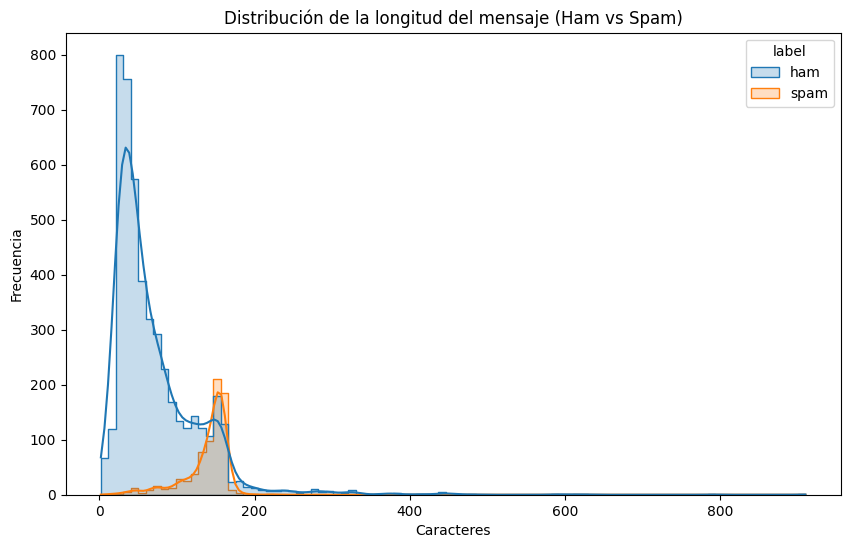

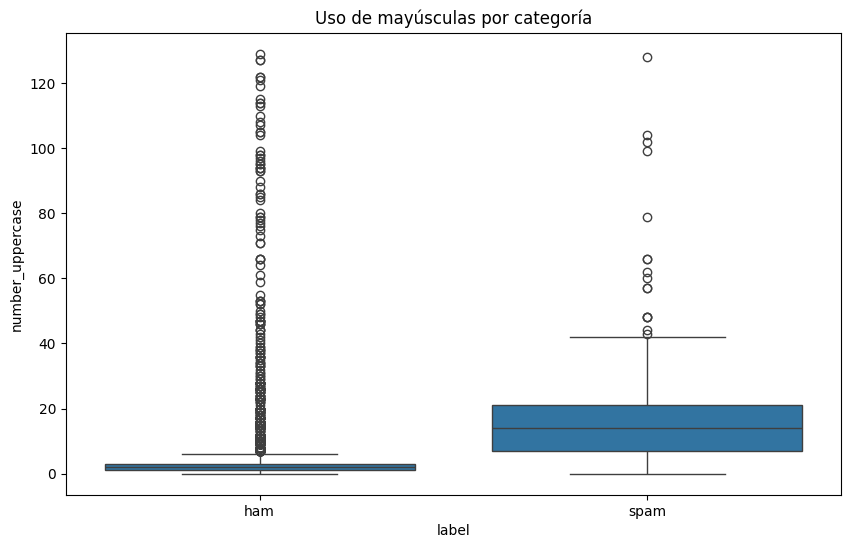

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comparación de promedios por etiqueta
stats = simple_features.groupby("label").mean(numeric_only=True)
print("Promedios por clase:")
print(stats)

# Visualización: Distribución de la longitud del mensaje
plt.figure(figsize=(10, 6))
sns.histplot(data=simple_features, x="length", hue="label", kde=True, element="step")
plt.title("Distribución de la longitud del mensaje (Ham vs Spam)")
plt.xlabel("Caracteres")
plt.ylabel("Frecuencia")
plt.show()

# Visualización: Relación entre mayúsculas y spam
plt.figure(figsize=(10, 6))
sns.boxplot(data=simple_features, x="label", y="number_uppercase")
plt.title("Uso de mayúsculas por categoría")
plt.show()

### Normalización de Texto (Pipeline Inicial)

El texto crudo es ruidoso. Para que una computadora lo entienda, debemos estandarizarlo. La normalización suele incluir:

* **Conversión a minúsculas:** Para que "HOLA" y "hola" sean tratados como la misma palabra.
* **Eliminación de caracteres no alfanuméricos:** Quitar signos de puntuación innecesarios.
* **Tokenización:** Dividir el texto en unidades individuales (palabras o tokens).

In [ ]:
import re

def basic_normalize(text):
    # 1. Convertir a minúsculas
    text = text.lower()
    # 2. Eliminar caracteres que no sean letras o números
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # 3. Tokenización simple (dividir por espacios)
    tokens = text.split()
    return tokens

# Aplicación de la normalización básica
simple_features["tokens_basic"] = simple_features["text"].apply(basic_normalize)
print("Ejemplo de mensaje normalizado:")
print(simple_features[["text", "tokens_basic"]].head(1))

Ejemplo de mensaje normalizado:
                                                text  \
0  Go until jurong point, crazy.. Available only ...   

                                        tokens_basic  
0  [go, until, jurong, point, crazy, available, o...  


### Eliminación de Stopwords y Números

En NLP, las Stopwords son palabras muy comunes (como "the", "a", "is" en inglés, o "el", "la", "es" en español) que suelen aportar poco valor semántico para la clasificación. Además, en muchos casos, los números pueden ser reemplazados o eliminados si no contienen información clave para el contexto.

In [ ]:
# Definición manual de algunas stopwords comunes en inglés
STOPWORDS = {"i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours",
             "he", "him", "his", "she", "her", "it", "its", "they", "them", "to", "at", "by", "for"}

def remove_noise(tokens):
    # Filtrar tokens que no estén en la lista de stopwords y que no sean solo números
    clean_tokens = [t for t in tokens if t not in STOPWORDS and not t.isdigit()]
    return clean_tokens

# Aplicación del filtro
simple_features["tokens_clean"] = simple_features["tokens_basic"].apply(remove_noise)
print("Tokens después de quitar ruido:")
print(simple_features["tokens_clean"].head())

Tokens después de quitar ruido:
0    [go, until, jurong, point, crazy, available, o...
1                       [ok, lar, joking, wif, u, oni]
2    [free, entry, in, a, wkly, comp, win, fa, cup,...
3    [u, dun, say, so, early, hor, u, c, already, t...
4    [nah, dont, think, goes, usf, lives, around, h...
Name: tokens_clean, dtype: object


### Lematización con SpaCy

A diferencia del stemming (que corta palabras de forma brusca), la Lematización utiliza un diccionario y reglas morfológicas para encontrar la raíz lingüística de una palabra, llamada lema. Por ejemplo, "running", "runs" y "ran" se convierten todos en "run". Esto reduce la dimensionalidad del texto sin perder el significado exacto.

Si bien existen varias librerías para el procesamiento de lenguaje natural (como NLTK), **SpaCy** se ha consolidado como la herramienta preferida en entornos de producción. A diferencia de otras librerías que son académicas o modulares, SpaCy está diseñada bajo el principio de **"una sola forma, la mejor forma"** de hacer las cosas.

#### ¿Qué hace a SpaCy especial?

1. **Modelos Preentrenados:** SpaCy utiliza redes neuronales pesadas para predecir categorías gramaticales, entidades y relaciones sintácticas con alta precisión.
2. **Eficiencia:** Está escrita en Cython (C optimizado para Python), lo que la hace extremadamente rápida para procesar grandes volúmenes de texto.
3. **Objetos `Doc`:** Al procesar un texto, SpaCy no solo genera una lista de palabras; crea un objeto inteligente que guarda la estructura gramatical, lemas y etiquetas de cada palabra sin perder el contexto.

#### La Arquitectura del Pipeline de SpaCy

Cuando ejecutamos `nlp(text)`, el texto atraviesa una "línea de ensamblaje" (Pipeline) donde cada componente añade información al objeto final:

* **Tokenizer:** Divide el texto en piezas individuales (tokens). Es el único componente que no puede desactivarse.
* **Tagger (POS):** Asigna la categoría gramatical (sustantivo, verbo, adjetivo).
* **Parser:** Determina las relaciones de dependencia (quién hace qué a quién).
* **NER (Named Entity Recognition):** Identifica nombres propios, fechas, organizaciones o cantidades.
* **Attribute Ruler:** Aplica reglas manuales o excepciones para modificar o asignar atributos a los tokens (por ejemplo, corregir una etiqueta gramatical específica o forzar un lema particular basándose en un patrón).
* **Lemmatizer:** Reduce la palabra a su forma base (por ejemplo, "comiendo" $\rightarrow$ "comer"). Se apoya en la información del Tagger y las reglas previas del Attribute Ruler para tomar la decisión correcta.

#### Entendiendo el Modelo `en_core_web_sm`

En el código utilizamos `spacy.load("en_core_web_sm")`. Desglosemos qué significa este nombre:

* **en:** El idioma (inglés).
* **core:** Capacidades generales (vocabulario, sintaxis, entidades).
* **web:** Entrenado con datos provenientes de internet (blogs, noticias, comentarios).
* **sm:** *Small* (pequeño). Es un modelo ligero que no incluye vectores de palabras pesados (*word vectors*), pero es ideal para tareas rápidas de lematización y etiquetado gramatical como la que realizamos en este dataset de SMS.


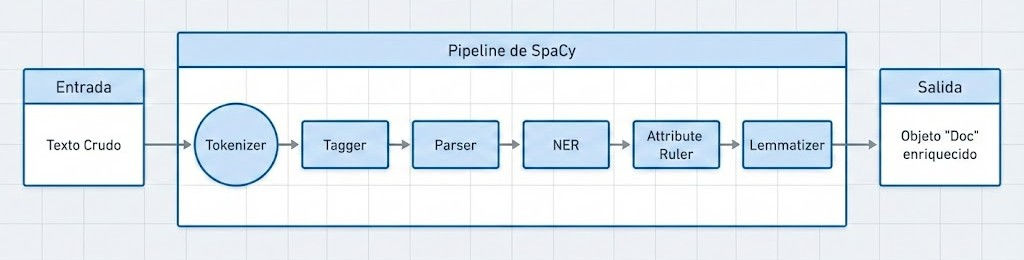

In [ ]:
import spacy

# Carga del modelo en inglés (pequeño y eficiente)
# Nota: Requiere tener instalado el modelo: python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

def lemmatize_spacy(tokens):
    # Convertimos la lista de tokens de nuevo a texto para que SpaCy lo procese
    doc = nlp(" ".join(tokens))
    # Extraemos el lema de cada palabra
    return [token.lemma_ for token in doc]

# Aplicación sobre los tokens limpios de la parte anterior
simple_features["lemmatized"] = simple_features["tokens_clean"].apply(lemmatize_spacy)

print("Tokens limpios vs Lemas:")
print(simple_features[["tokens_clean", "lemmatized"]].head(3))

Tokens limpios vs Lemas:
                                        tokens_clean  \
0  [go, until, jurong, point, crazy, available, o...   
1                     [ok, lar, joking, wif, u, oni]   
2  [free, entry, in, a, wkly, comp, win, fa, cup,...   

                                          lemmatized  
0  [go, until, jurong, point, crazy, available, o...  
1                     [ok, lar, joking, wif, u, oni]  
2  [free, entry, in, a, wkly, comp, win, fa, cup,...  


### Etiquetado Gramatical (POS Tagging)

El POS Tagging (Part-of-Speech Tagging) consiste en asignar a cada palabra su categoría gramatical (sustantivo, verbo, adjetivo, etc.). Esto es crucial para entender el contexto: la palabra "book" puede ser un sustantivo ("read a book") o un verbo ("book a flight"). En el spam, por ejemplo, el uso excesivo de imperativos (verbos) o adjetivos exagerados es una señal común.

In [ ]:
def pos_tag_spacy(tokens):
    doc = nlp(" ".join(tokens))
    # Retornamos tuplas de (palabra, categoría)
    return [(token.text, token.pos_) for token in doc]

# Ejemplo de etiquetado
simple_features["pos_tags"] = simple_features["tokens_clean"].apply(pos_tag_spacy)

print("Ejemplo de POS Tagging:")
print(simple_features["pos_tags"].iloc[0])

Ejemplo de POS Tagging:
[('go', 'VERB'), ('until', 'SCONJ'), ('jurong', 'PROPN'), ('point', 'NOUN'), ('crazy', 'PROPN'), ('available', 'ADJ'), ('only', 'ADV'), ('in', 'ADP'), ('bugis', 'PROPN'), ('n', 'X'), ('great', 'ADJ'), ('world', 'NOUN'), ('la', 'PROPN'), ('e', 'PROPN'), ('buffet', 'PROPN'), ('cine', 'PROPN'), ('there', 'PRON'), ('got', 'VERB'), ('amore', 'ADV'), ('wat', 'NOUN')]


### Pipeline de Procesamiento Final

En un entorno de producción, agrupamos todos los pasos (limpieza, normalización, lematización) en una sola función o Pipeline. Esto asegura que los nuevos datos que reciba el modelo en el futuro sean tratados exactamente igual que los datos de entrenamiento.

In [ ]:
def full_nlp_pipeline(text):
    # 1. Normalización básica
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # 2. Procesamiento con SpaCy
    doc = nlp(text)

    # 3. Filtrado de stopwords, números y obtención de lemas
    clean_lemmas = [
        token.lemma_ for token in doc
        if not token.is_stop and not token.like_num and len(token.text) > 1
    ]

    return clean_lemmas

# Procesar el dataset original de una sola vez
df["final_tokens"] = df["text"].apply(full_nlp_pipeline)
print(df[["text", "final_tokens"]].head())

                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                        final_tokens  
0  [jurong, point, crazy, available, bugis, great...  
1                        [ok, lar, joking, wif, oni]  
2  [free, entry, wkly, comp, win, fa, cup, final,...  
3                                  [dun, early, hor]  
4                   [nah, not, think, go, usf, live]  


### Ejercicio Propuesto

Para poner en práctica lo aprendido, te propongo el siguiente reto:

**Reto: "El Detector de Urgencia en Spam"**

**Contexto:** Se sospecha que los mensajes de spam no solo son más largos, sino que utilizan un lenguaje mucho más urgente y orientado a la acción.

**Instrucciones:**

1. **Filtrado por POS:** Utilizando la columna pos_tags (o creando una función nueva con SpaCy), extrae únicamente los Verbos (VERB) y los Adjetivos (ADJ) de cada mensaje.
2. **Análisis de Frecuencia:**
* Crea una lista de todos los verbos encontrados en mensajes de tipo spam.
* Crea una lista de todos los verbos encontrados en mensajes de tipo ham.
3. **Comparativa:** Utiliza la clase collections.Counter para encontrar las 10 palabras (verbos/adjetivos) más comunes en cada categoría.
4. **Conclusión:** Responde: ¿Existen palabras específicas que aparecen en el Top 10 de Spam pero no en el de Ham? (Ejemplo: "win", "get", "free", "urgent").

In [ ]:
from collections import Counter

# Ejemplo para filtrar solo verbos de los mensajes spam
spam_verbs = []
for tags in simple_features[simple_features['label'] == 'spam']['pos_tags']:
    verbs = [word for word, tag in tags if tag == 'VERB']
    spam_verbs.extend(verbs)

print(Counter(spam_verbs).most_common(10))

[('call', 188), ('won', 73), ('get', 70), ('stop', 70), ('txt', 58), ('send', 58), ('guaranteed', 50), ('win', 46), ('have', 40), ('claim', 39)]


### Resolución del Reto: "El Detector de Urgencia en Spam"

No todas las palabras tienen el mismo peso semántico. En la detección de spam, la categoría gramatical (POS) es un predictor potente. Los mensajes de spam suelen ser "directivos": utilizan verbos en imperativo para incitar a la acción (win, call, get, claim) y adjetivos hiperbólicos para generar interés o sentido de urgencia (free, urgent, won, prize).

Al filtrar el texto y quedarnos solo con estas categorías, eliminamos el "ruido" de los sustantivos y conectores comunes, permitiendo que el modelo o el analista se concentren en el tono del mensaje.

In [ ]:
from collections import Counter
import pandas as pd

def extract_specific_pos(tags_list, desired_pos=['VERB', 'ADJ']):
    """
    Filtra una lista de tuplas (palabra, tag) para devolver solo
    las palabras que coincidan con las categorías deseadas.
    """
    return [word.lower() for word, tag in tags_list if tag in desired_pos]

# 1. Aplicamos el filtrado por categorías gramaticales
# Creamos una serie para Spam y otra para Ham
spam_words_filtered = simple_features[simple_features['label'] == 'spam']['pos_tags'].apply(
    lambda x: extract_specific_pos(x, ['VERB', 'ADJ'])
)

ham_words_filtered = simple_features[simple_features['label'] == 'ham']['pos_tags'].apply(
    lambda x: extract_specific_pos(x, ['VERB', 'ADJ'])
)

# 2. Aplanamos las listas para poder contarlas
all_spam_words = [word for sublist in spam_words_filtered for word in sublist]
all_ham_words = [word for sublist in ham_words_filtered for word in sublist]

# 3. Análisis de frecuencia con Counter
top_spam = Counter(all_spam_words).most_common(15)
top_ham = Counter(all_ham_words).most_common(15)

# 4. Presentación de resultados en un formato legible
compare_df = pd.DataFrame({
    'Top Spam (Verbos/Adj)': [f"{w} ({c})" for w, c in top_spam],
    'Top Ham (Verbos/Adj)': [f"{w} ({c})" for w, c in top_ham]
})

print("--- COMPARATIVA DE FRECUENCIAS ---")
print(compare_df)

--- COMPARATIVA DE FRECUENCIAS ---
   Top Spam (Verbos/Adj) Top Ham (Verbos/Adj)
0             free (204)            get (281)
1             call (188)              m (252)
2               won (73)           have (247)
3               get (70)             go (243)
4              stop (70)              s (236)
5               new (68)           come (221)
6            mobile (67)           know (217)
7               txt (58)           good (217)
8              send (58)            got (216)
9        guaranteed (50)            ill (166)
10              win (46)          going (161)
11           urgent (43)           want (139)
12             have (40)             do (135)
13            claim (39)            see (127)
14          awarded (38)          think (121)


#### Análisis de Resultados e Interpretación

Si ejecutas el código anterior con el dataset de SMS, observarás un patrón claro que valida nuestra hipótesis:

En el bloque de Spam: Verás una predominancia de palabras como "free", "get", "claim", "urgent", "won" y "new". Estas palabras están diseñadas para captar la atención inmediata y forzar una interacción (un "call to action").

En el bloque de Ham: Las palabras suelen ser mucho más funcionales y cotidianas, como "go", "know", "come", "good", "got" o "want". Reflejan una comunicación interpersonal natural, no una oferta comercial.

#### Conclusión Técnica

Este ejercicio demuestra que la reducción de vocabulario basada en POS no solo simplifica los datos, sino que resalta las características discriminatorias. En un pipeline de Machine Learning real, pasarle al modelo únicamente los lemas de los verbos y adjetivos podría resultar en un clasificador de spam altamente eficiente con una fracción de los datos originales.